In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Análisis de Datos de Hipotecarios Marginales
En este notebook se realizará la evaluación de calidad, limpieza, análisis exploratorio y transformación de los datos provenientes de "Hipotecarios_Marginales.csv".

In [2]:
# Leer el archivo CSV
archivo = "Hipotecarios_Marginales.csv"
df = pd.read_csv(archivo, encoding='utf-8', engine='python', on_bad_lines='skip')

# Sección para explorar y evaluar la calidad de los datos

In [3]:
# Primeras 5 filas del DataFrame
print(df.head())

                sector  cve_periodo nombre_publicacion  \
0  BANCA DE DESARROLLO       201901           Banobras   
1  BANCA DE DESARROLLO       201902         Banjército   
2  BANCA DE DESARROLLO       201902         Banjército   
3  BANCA DE DESARROLLO       201902         Banjército   
4  BANCA DE DESARROLLO       201902           Banobras   

                         dl_estado    dl_municipio  dat_ingreso_mensual_bruto  \
0                           MÉXICO  VALLE DE BRAVO                   63832.00   
1                 CIUDAD DE MÉXICO      IZTAPALAPA                   30589.15   
2                          JALISCO         ZAPOPAN                   30809.40   
3  VERACRUZ DE IGNACIO DE LA LLAVE        VERACRUZ                   42052.66   
4                 CIUDAD DE MÉXICO   BENITO JUAREZ                   39576.00   

   dat_valor_vivienda_originacion     tipo_acreditado dl_tipo_comprobacion  \
0                      4805397.12  Asalariado Público           Asalariado   
1       

In [4]:
#Información general del DataFrame
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1431308 entries, 0 to 1431307
Data columns (total 18 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   sector                          1431308 non-null  object 
 1   cve_periodo                     1431308 non-null  int64  
 2   nombre_publicacion              1431308 non-null  object 
 3   dl_estado                       1431308 non-null  object 
 4   dl_municipio                    1431308 non-null  object 
 5   dat_ingreso_mensual_bruto       1431308 non-null  float64
 6   dat_valor_vivienda_originacion  1431308 non-null  float64
 7   tipo_acreditado                 1431308 non-null  object 
 8   dl_tipo_comprobacion            1431308 non-null  object 
 9   dat_ai_edad_acred               1431308 non-null  float64
 10  dl_genero                       1431308 non-null  object 
 11  numero de crédito               1431308 non-null  object 
 12  

In [5]:
#Cantidad de valores nulos en cada columna
print(df.isnull().sum())

sector                               0
cve_periodo                          0
nombre_publicacion                   0
dl_estado                            0
dl_municipio                         0
dat_ingreso_mensual_bruto            0
dat_valor_vivienda_originacion       0
tipo_acreditado                      0
dl_tipo_comprobacion                 0
dat_ai_edad_acred                    0
dl_genero                            0
numero de crédito                    0
dat_monto_orig_cred                  0
dl_destino_credito                   0
dl_producto_hipotecario           1052
Tipo de Crédito                      0
dl_segmento_vivienda                 0
tasa_ponderada                       0
dtype: int64


Dado que el área donde están los nulos, de momento, no es de nuestro interés, no voy a eliminar las columnas ni sustituirlas por algún otro valor, como podría hacerse en un caso numérico con la media de los datos.

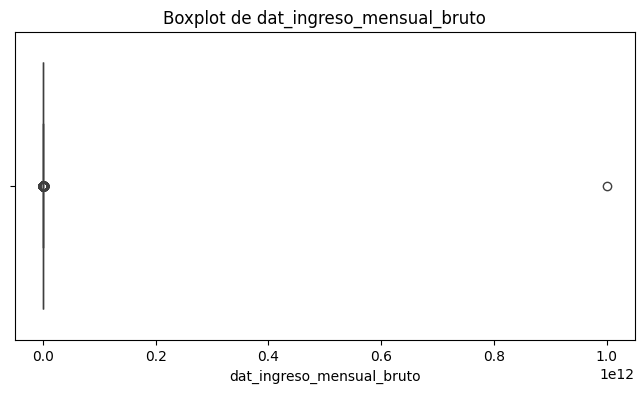

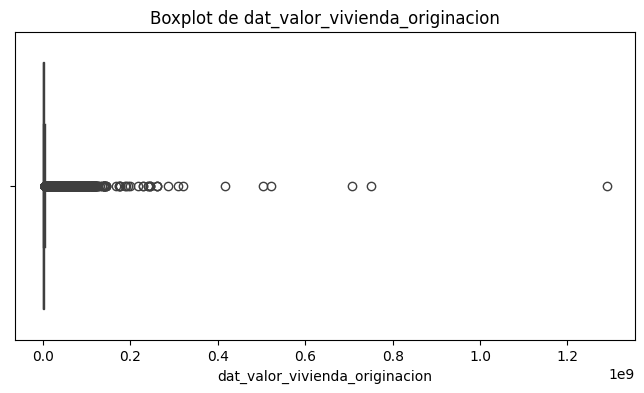

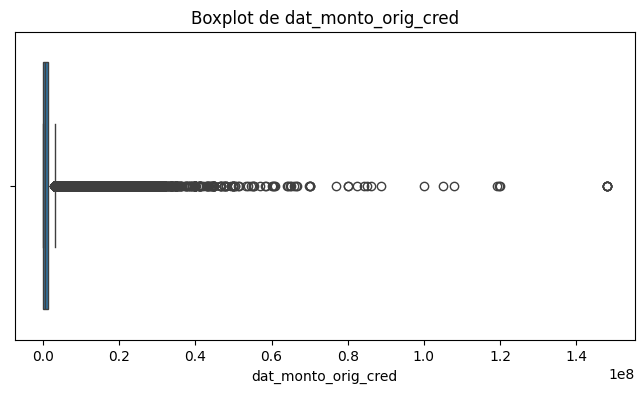

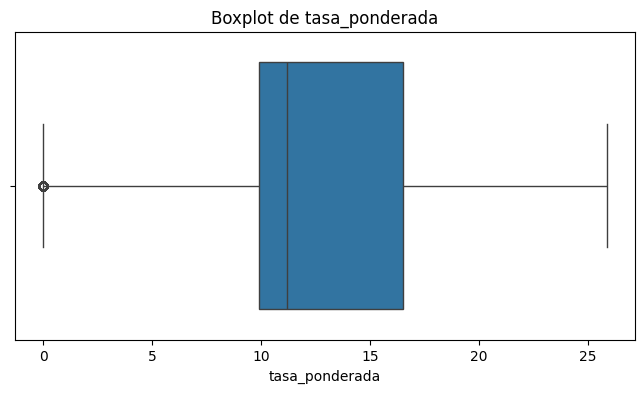

In [6]:
# Seleccionar columnas numéricas importantes, excluyendo 'cve_periodo' y 'dat_ai_edad_acred'
columnas_importantes = [col for col in df.select_dtypes(include=[float, int]).columns 
                         if col not in ['cve_periodo', 'dat_ai_edad_acred']]

# Generar un boxplot para cada columna importante para identificar visualmente outliers.
for col in columnas_importantes:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)
    plt.show()

# Limpieza de datos y outliers

In [7]:
# Guardar la longitud original del DataFrame
longitud_original = len(df)

# Eliminar registros duplicados
df = df.drop_duplicates()

# Obtener la longitud del DataFrame después de eliminar duplicados
longitud_modificada = len(df)

# Mostrar el impacto de la eliminación de duplicados
print("\nNúmero de registros antes de eliminar duplicados:", longitud_original)
print("Número de registros después de eliminar duplicados:", longitud_modificada)
print("Total de registros eliminados:", longitud_original - longitud_modificada)


Número de registros antes de eliminar duplicados: 1431308
Número de registros después de eliminar duplicados: 1431308
Total de registros eliminados: 0


#### Ejemplo de dato que claramente es un outlier o error de registro de ingreso mensual bruto

In [8]:
# Definir un umbral manual para identificar outliers en la columna 'dat_ingreso_mensual_bruto'
umbral = 1e10

# Extraer las filas donde 'dat_ingreso_mensual_bruto' supera el umbral
df_outliers = df[df['dat_ingreso_mensual_bruto'] > umbral]
display(df_outliers)

,sector,cve_periodo,nombre_publicacion,dl_estado,dl_municipio,dat_ingreso_mensual_bruto,dat_valor_vivienda_originacion,tipo_acreditado,dl_tipo_comprobacion,dat_ai_edad_acred,dl_genero,numero de crédito,dat_monto_orig_cred,dl_destino_credito,dl_producto_hipotecario,Tipo de Crédito,dl_segmento_vivienda,tasa_ponderada
1053535,BANCA MÚLTIPLE,202204,BBVA México,COAHUILA DE ZARAGOZA,SALTILLO,1.000000e+12,3345000.0,Asalariado Privado,Asalariado,50.0,Femenino,Crédito 2490,2600000.0,Adquisición de Vivienda Usada,"Adquisicion Pesos Tasa Fija, Casa Media",Sin cofinanciamiento,Media o Residencial,7.8


## Detección de Outliers usando la Regla del IQR

In [9]:
"""
Elimina outliers de las columnas especificadas en el DataFrame usando la regla del IQR.
    
Parámetros:
- df: DataFrame original.
- columnas: Lista de nombres de columnas en las que se desea aplicar la eliminación de outliers.
    
Regresa:
- Un nuevo DataFrame sin los outliers en las columnas especificadas.
"""

def regla_IQR(df,columnas):
    
    df_filtrado = df.copy()
    
    for col in columnas:
        # Calcular el primer y tercer cuartil para la columna
        q1 = df_filtrado[col].quantile(0.25)
        q3 = df_filtrado[col].quantile(0.75)
        iqr = q3 - q1
        
        # Definir límites inferior y superior
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        # Filtrar filas que se encuentren dentro de los límites
        df_filtrado = df_filtrado[(df_filtrado[col] >= lower_bound) & (df_filtrado[col] <= upper_bound)]
    
    return df_filtrado

In [10]:
# Aplicar la función para eliminar outliers en las columnas importantes.
df_sin_outliers = regla_IQR(df, columnas_importantes)
df_sin_outliers['cve_periodo'] = pd.to_datetime(df_sin_outliers['cve_periodo'].astype(str), format='%Y%m')
# Mostrar la cantidad de registros antes y después de la eliminación de outliers.
longitud_original = len(df)
longitud_modificada = len(df_sin_outliers)
print("\nNúmero de registros original:", longitud_original)
print("Número de registros después de eliminar outliers:", longitud_modificada)
print("Total de registros eliminados por outliers:", longitud_original - longitud_modificada)


Número de registros original: 1431308
Número de registros después de eliminar outliers: 1186549
Total de registros eliminados por outliers: 244759


#### Se eliminaron bastantes filas, por lo que sería conveniente realizar una exploración más profunda de la eliminación de outliers. En una primera exploración visual se observa que, seguramente, las variables que más datos eliminaron fueron `dat_valor_vivienda_originacion` y `dat_monto_orig_cred`, las cuales son datos importantes; sin embargo, para fines de este ejercicio lo dejaré así.

## Visualización de los datos despues de elimnar los outliers

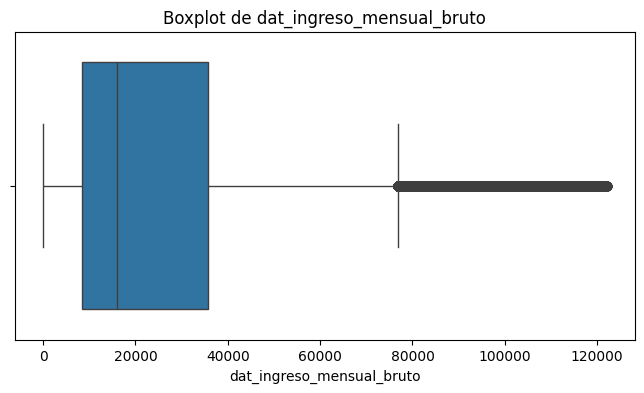

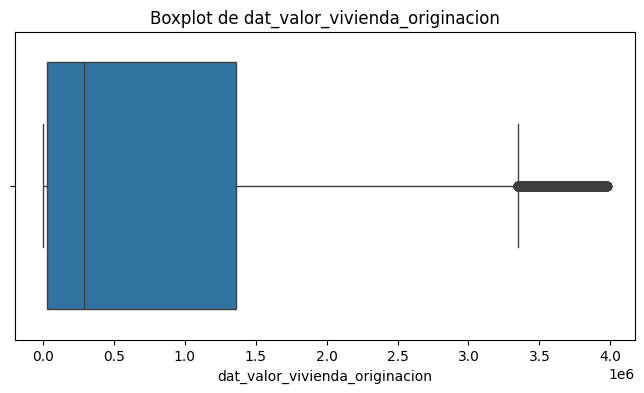

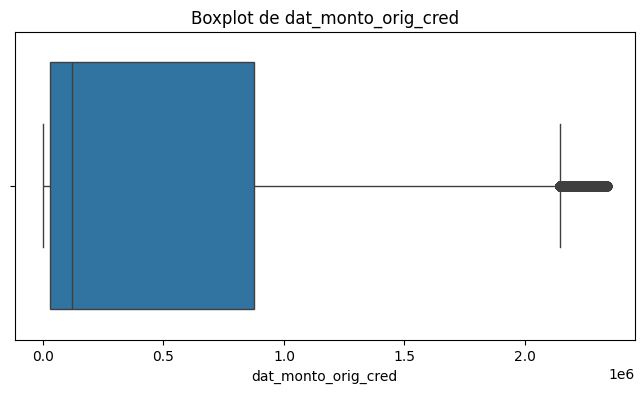

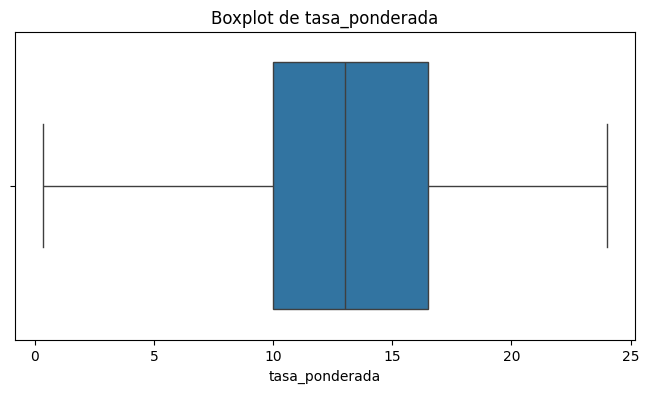

In [11]:
for col in columnas_importantes:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_sin_outliers[col])
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)
    plt.show()

# Extracción de la información que nos interesa

In [12]:
# Definir los nombres de las entidades y el campo a usar para filtrado. Son arreglos paralelos por lo que si uno aumenta de tamaño el 
#otro tambien debe aumentar con el los datos correctos. 
nombres = ['Scotiabank','BBVA México','Inbursa','BANCA MÚLTIPLE']
tipo = ['nombre_publicacion','nombre_publicacion','nombre_publicacion','sector']

# Crear una lista para almacenar los DataFrames segmentados.
dfs = []

for id in range(len(nombres)):
    dfs.append(df_sin_outliers[df_sin_outliers[tipo[id]] == nombres[id]].reset_index(drop=True))

In [13]:
"""
Agrupa el DataFrame por 'dl_destino_credito' y cuenta la cantidad de registros en cada grupo.
    
Parámetros:
- df: DataFrame a agrupar.
    
Regresa:
- Un diccionario con el destino de crédito como clave y la cantidad de registros como valor.
"""
def destino_de_creditos(df):
    # Agrupar por 'dl_destino_credito'
    dfs_por_dl_destino_credito = {dl_destino_credito: df_dl_destino_credito for dl_destino_credito, df_dl_destino_credito in df.groupby('dl_destino_credito')}
    
    # Crear un diccionario para guardar la longitud de cada grupo
    longitudes = {}
    
    for key, df_temp in dfs_por_dl_destino_credito.items():
        longitudes[key] = len(df_temp)

    return longitudes 

In [14]:
for idx, nombre in enumerate(nombres):
    print("=" * 60)
    print(f"Datos de: {nombre}")
    print("=" * 60)
    
    # Obtener el resultado para el DataFrame actual
    resultados = destino_de_creditos(dfs[idx])
    print(len(resultados))
    # Imprimir cada destino de crédito y su cantidad formateados
    for destino, cantidad in resultados.items():
        print(f"{destino:<50}: {cantidad}")
        
    print("\n")  # Salto de línea entre cada grupo

Datos de: Scotiabank
9
Adquisición de Terreno y Construcción Simultánea  : 508
Adquisición de Vivienda Nueva                     : 62970
Adquisición de Vivienda Usada                     : 7797
Construcción de Vivienda Propia                   : 727
Crédito Para Liquidez                             : 496
Crédito Para Líquidez                             : 887
Créditos a exempleados de la Entidad              : 385
Mejoras, Ampliaciones y/o Remodelaciones          : 231
Pago de Pasivos Hipotecarios                      : 3253


Datos de: BBVA México
8
Adquisición de Terreno para Vivienda              : 1503
Adquisición de Vivienda Nueva                     : 73309
Adquisición de Vivienda Usada                     : 85277
Crédito Para Liquidez                             : 2271
Crédito Para Líquidez                             : 4472
Créditos a exempleados de la Entidad              : 2202
Mejoras, Ampliaciones y/o Remodelaciones          : 397
Pago de Pasivos Hipotecarios               

In [15]:
# dfs[3] contien el DataFrame de la BANCA MÚLTIPLE
df_banca = dfs[3]

# Definir las fechas límite para octubre 2023 y octubre 2024
fecha_limite24 = pd.to_datetime("2024-10", format="%Y-%m")
fecha_limite23 = pd.to_datetime("2023-10", format="%Y-%m")

# Filtrar los registros hasta la fecha límite para cada año
df_banca_hasta_oct24 = df_banca[df_banca['cve_periodo'] <= fecha_limite24]
df_banca_hasta_oct23 = df_banca[df_banca['cve_periodo'] <= fecha_limite23]

# Agrupar por 'dl_destino_credito' y sumar el saldo acumulado ('dat_monto_orig_cred') en cada periodo
grupo_oct24 = df_banca_hasta_oct24.groupby('dl_destino_credito')['dat_monto_orig_cred'].sum().reset_index()
grupo_oct24 = grupo_oct24.rename(columns={'dat_monto_orig_cred':'Saldo Oct24'})

grupo_oct23 = df_banca_hasta_oct23.groupby('dl_destino_credito')['dat_monto_orig_cred'].sum().reset_index()
grupo_oct23 = grupo_oct23.rename(columns={'dat_monto_orig_cred':'Saldo Oct23'})

# Combinar ambos resultados en una tabla comparativa
tabla_comparativa = pd.merge(grupo_oct23, grupo_oct24, on='dl_destino_credito', how='outer').fillna(0)

# Calcular el delta de crecimiento (% de variación) para cada destino
tabla_comparativa['Delta (%)'] = ((tabla_comparativa['Saldo Oct24'] - tabla_comparativa['Saldo Oct23']) / tabla_comparativa['Saldo Oct23']) * 100

# Mostrar la tabla final
display(tabla_comparativa)

,dl_destino_credito,Saldo Oct23,Saldo Oct24,Delta (%)
0,Adquisición de Terreno para Vivienda,5.362685e+09,5.985019e+09,11.604896
1,Adquisición de Terreno y Construcción Simultánea,1.359746e+09,1.380693e+09,1.540485
2,Adquisición de Vivienda Nueva,3.542068e+11,3.727842e+11,5.244776
3,Adquisición de Vivienda Usada,1.178459e+11,1.257942e+11,6.744668
4,Autoproducción de vivienda,6.880196e+07,8.165542e+07,18.681828
5,Construcción de Vivienda Propia,3.736602e+09,4.037179e+09,8.044112
6,Crédito Para Liquidez,4.675238e+09,5.727523e+09,22.507619
7,Crédito Para Líquidez,7.360954e+09,7.360954e+09,0.000000
8,Créditos a exempleados de la Entidad,4.727224e+09,4.964440e+09,5.018092
9,"Mejoras, Ampliaciones y/o Remodelaciones",2.559438e+10,2.584172e+10,0.966400


In [16]:


# Utilizamos ExcelWriter para guardar cada DataFrame en una hoja separada
with pd.ExcelWriter("Entregable_Hipotecas.xlsx", engine="xlsxwriter") as writer:
    # Guardar el DataFrame completo para Scotiabank
    dfs[0].to_excel(writer, sheet_name="Scotiabank", index=False)
    
    # Guardar el DataFrame completo para BBVA México
    dfs[1].to_excel(writer, sheet_name="BBVA México", index=False)
    
    # Guardar el DataFrame completo para Inbursa
    dfs[2].to_excel(writer, sheet_name="Inbursa", index=False)
    
    # Guardar la tabla comparativa de BANCA MÚLTIPLE (agrupada por dl_destino_credito)
    tabla_comparativa.to_excel(writer, sheet_name="Banca Múltiple", index=False)

print("El archivo 'Entregable_Hipotecas.xlsx' se ha creado correctamente con las hojas correspondientes.")

El archivo 'Entregable_Hipotecas.xlsx' se ha creado correctamente con las hojas correspondientes.
